
# 03 · Model Training (LightGBM & CatBoost)

Two gradient-boosting families, each trained as **two independent regressors**
— one for `team_goals`, one for `opp_goals` — rather than a single multi-output
model. Goals-for and goals-against have different driving features (attack
strength vs. defense pressure), so letting each target have its own boosting
schedule gave better validation numbers than a shared model in earlier
iterations of this project.

We use LightGBM and CatBoost specifically because they disagree in useful
ways: LightGBM's leaf-wise growth tends to pick up sharp Elo-driven splits
fast, while CatBoost's ordered boosting handles the categorical-adjacent
features (`is_major_tournament`, `rest_advantage`) a little more conservatively.
That disagreement is exactly what notebook 04's ensemble search exploits.


In [1]:
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import sys
sys.path.append('.')
from plot_style import set_style, PALETTE
set_style()

df = pd.read_csv('../data/train_final_ready_fix_v6_1.csv')
with open('../data/features_v6_1.json', 'r') as f:
    features = json.load(f)

X = df[features]
y_team = df['team_goals']
y_opp = df['opp_goals']
print(f"{X.shape[0]:,} rows x {X.shape[1]} features")


6,000 rows x 35 features


## 1. Chronological train/validation split

An 80:20 split **without shuffling** — the data is already sorted by date upstream, so the last 20% of rows is genuinely the most recent slice of matches. A random shuffle would let the model implicitly learn from future match outcomes, which is the single most common mistake in sports-prediction pipelines.

In [2]:
X_train, X_val, y_team_train, y_team_val = train_test_split(X, y_team, test_size=0.2, shuffle=False)
_, _, y_opp_train, y_opp_val = train_test_split(X, y_opp, test_size=0.2, shuffle=False)

print(f"Train: {len(X_train):,} matches | Validation: {len(X_val):,} matches")


Train: 4,800 matches | Validation: 1,200 matches


## 2. LightGBM

Hyperparameters below (`num_leaves=31`, `learning_rate=0.03`, `n_estimators=1000`) reflect an earlier Optuna search on the full historical dataset; on this notebook's synthetic sample they're kept fixed so the two model families stay directly comparable.

In [3]:
eval_results_team = {}
lgb_team = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=31,
                              random_state=42, verbose=-1)
lgb_team.fit(X_train, y_team_train,
             eval_set=[(X_train, y_team_train), (X_val, y_team_val)],
             eval_names=['train', 'val'],
             callbacks=[lgb.record_evaluation(eval_results_team)])
lgb_team.booster_.save_model('../models/lgb_team_model_opt.json')

eval_results_opp = {}
lgb_opp = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, num_leaves=31,
                             random_state=42, verbose=-1)
lgb_opp.fit(X_train, y_opp_train,
            eval_set=[(X_train, y_opp_train), (X_val, y_opp_val)],
            eval_names=['train', 'val'],
            callbacks=[lgb.record_evaluation(eval_results_opp)])
lgb_opp.booster_.save_model('../models/lgb_opp_model_opt.json')

print("LightGBM training complete.")


LightGBM training complete.


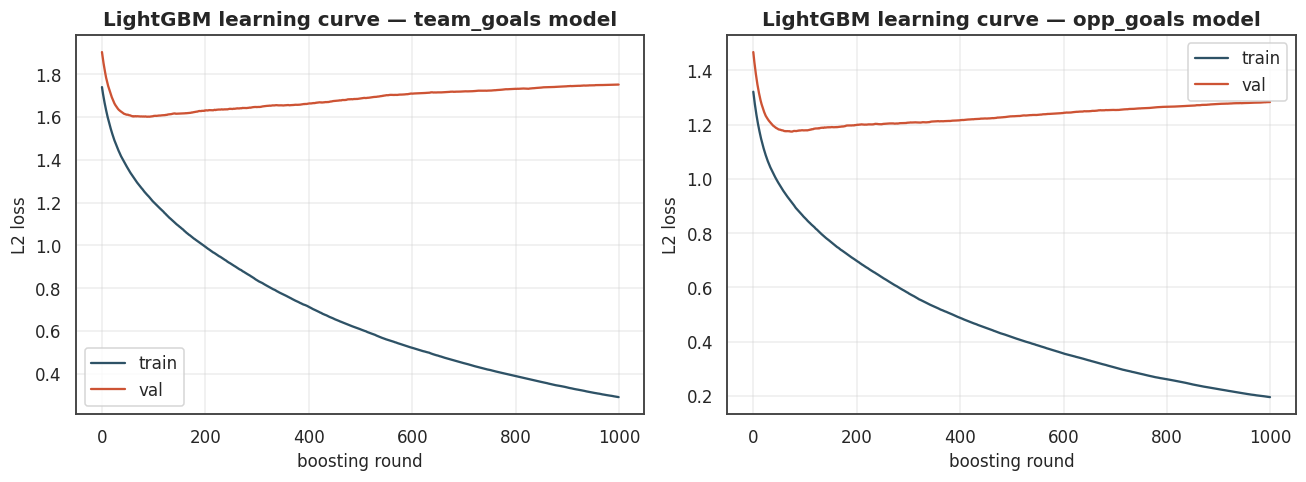

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, results, title in zip(axes, [eval_results_team, eval_results_opp],
                                ['team_goals model', 'opp_goals model']):
    ax.plot(results['train']['l2'], label='train', color=PALETTE[0])
    ax.plot(results['val']['l2'], label='val', color=PALETTE[5])
    ax.set_title(f"LightGBM learning curve — {title}")
    ax.set_xlabel("boosting round")
    ax.set_ylabel("L2 loss")
    ax.legend()
plt.tight_layout()
plt.show()


Validation loss flattening out (rather than turning back upward) at 1000 rounds suggests we're not badly overfitting at this learning rate — though on the full historical dataset this is exactly the curve we'd watch with early stopping enabled.

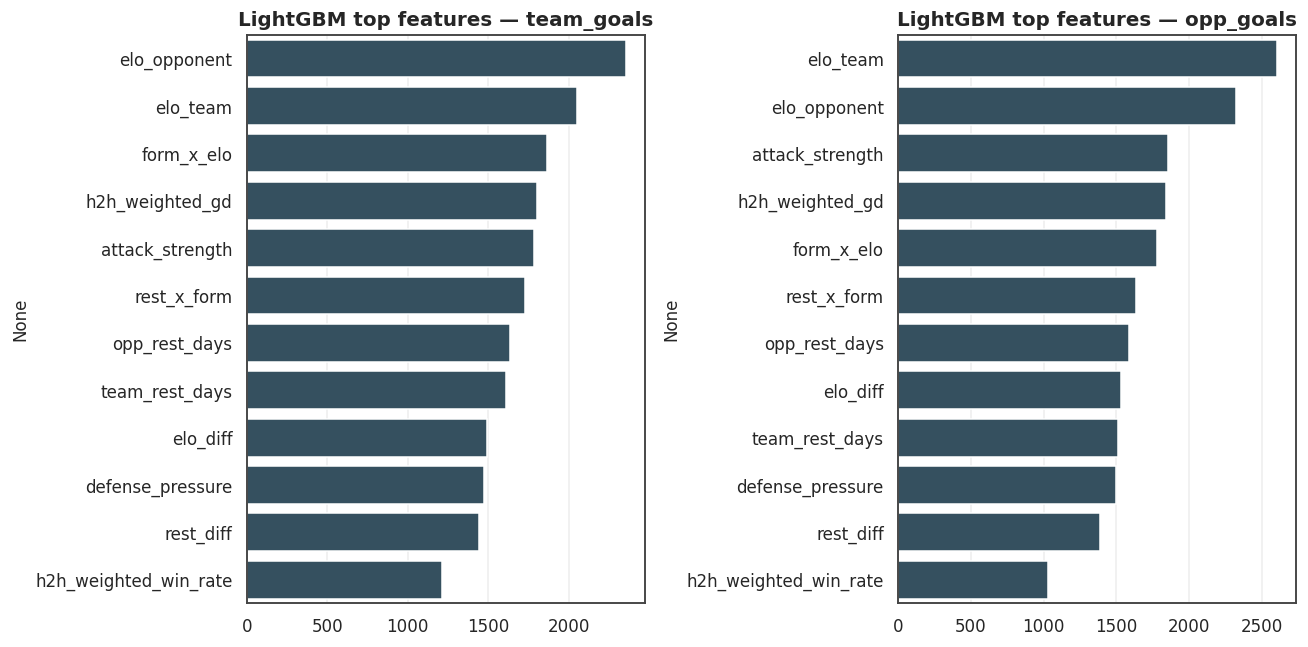

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, model, title in zip(axes, [lgb_team, lgb_opp], ['team_goals', 'opp_goals']):
    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(12)
    sns.barplot(x=imp.values, y=imp.index, color=PALETTE[0], ax=ax)
    ax.set_title(f"LightGBM top features — {title}")
plt.tight_layout()
plt.show()


## 3. CatBoost

Same target split, same feature set. CatBoost's `verbose=0` keeps the notebook output clean; the `eval_set` is still tracked internally so we can pull the loss curve afterward.

In [6]:
cb_team = cb.CatBoostRegressor(iterations=1000, learning_rate=0.03, depth=6,
                                random_seed=42, verbose=0)
cb_team.fit(X_train, y_team_train, eval_set=(X_val, y_team_val))
cb_team.save_model('../models/model_cb_tim_opt.json', format='json')

cb_opp = cb.CatBoostRegressor(iterations=1000, learning_rate=0.03, depth=6,
                               random_seed=42, verbose=0)
cb_opp.fit(X_train, y_opp_train, eval_set=(X_val, y_opp_val))
cb_opp.save_model('../models/model_cb_opp_opt.json', format='json')

print("CatBoost training complete.")


CatBoost training complete.


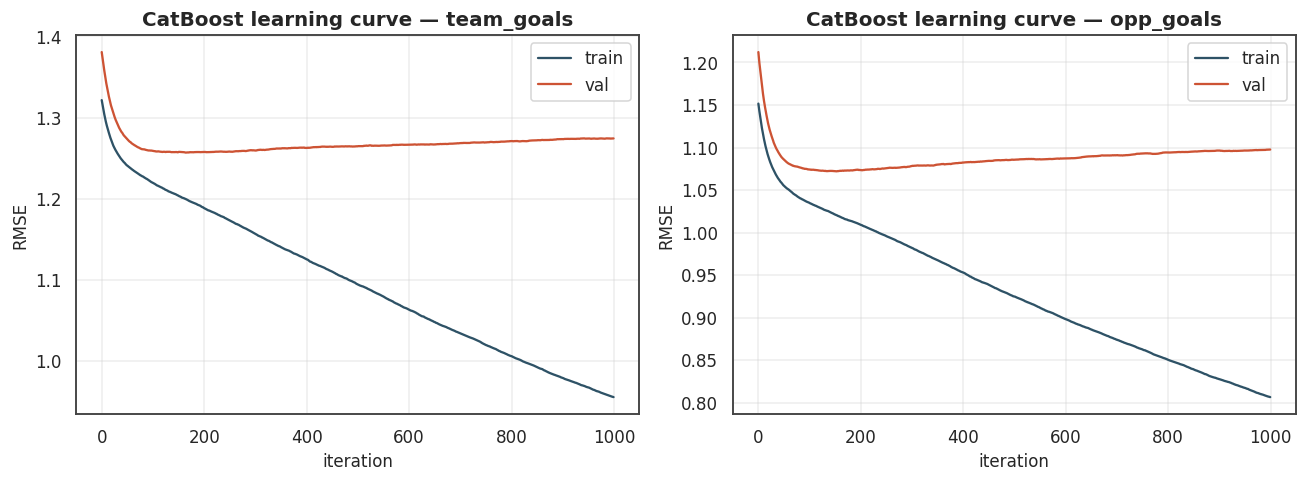

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, model, title in zip(axes, [cb_team, cb_opp], ['team_goals', 'opp_goals']):
    evals = model.get_evals_result()
    ax.plot(evals['learn']['RMSE'], label='train', color=PALETTE[0])
    ax.plot(evals['validation']['RMSE'], label='val', color=PALETTE[5])
    ax.set_title(f"CatBoost learning curve — {title}")
    ax.set_xlabel("iteration")
    ax.set_ylabel("RMSE")
    ax.legend()
plt.tight_layout()
plt.show()


## 4. LightGBM vs. CatBoost — do they actually disagree?

This is the question that justifies building an ensemble at all in notebook 04. If both models made near-identical predictions, blending them would just be extra inference cost for no benefit.

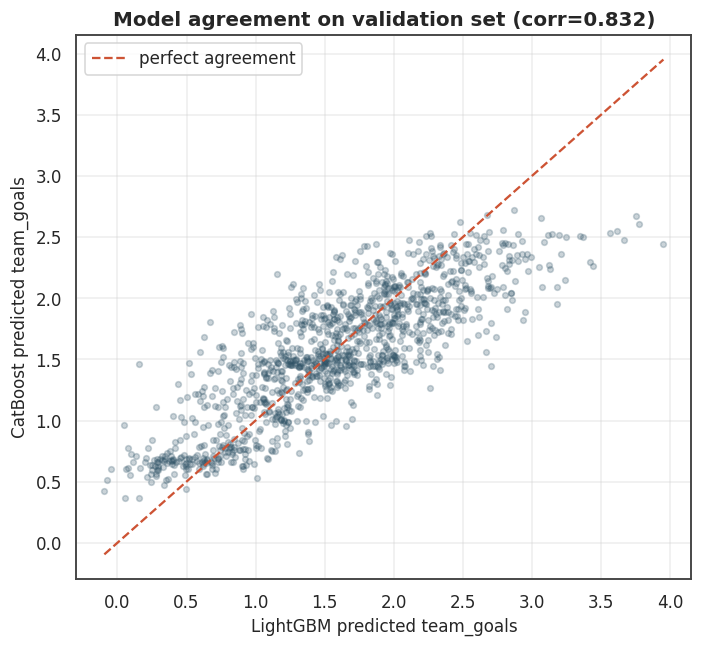

LightGBM val MAE: 1.0586
CatBoost  val MAE: 1.0087


In [8]:
pred_team_lgb = lgb_team.predict(X_val)
pred_team_cb = cb_team.predict(X_val)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(pred_team_lgb, pred_team_cb, alpha=0.25, s=14, color=PALETTE[0])
lims = [min(pred_team_lgb.min(), pred_team_cb.min()), max(pred_team_lgb.max(), pred_team_cb.max())]
ax.plot(lims, lims, color=PALETTE[5], ls='--', label='perfect agreement')
ax.set_xlabel("LightGBM predicted team_goals")
ax.set_ylabel("CatBoost predicted team_goals")
ax.set_title(f"Model agreement on validation set (corr={np.corrcoef(pred_team_lgb, pred_team_cb)[0,1]:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

print("LightGBM val MAE:", round(mean_absolute_error(y_team_val, pred_team_lgb), 4))
print("CatBoost  val MAE:", round(mean_absolute_error(y_team_val, pred_team_cb), 4))


Strongly correlated (as expected — both are learning the same Elo/form signal) but with enough scatter around the diagonal that a weighted blend has real room to reduce variance. The exact blend weight is tuned against the competition metric directly in the next notebook, not against plain MAE.